# run_copulaGNN (minimal, runnable demo)

This notebook shows a **working end-to-end run** using the two files you provided:

- `data.py` (graph/tabular dataset utilities + synthetic LSN generator)  
- `copula.py` (Gaussian Copula distribution)

It trains a **simple GCN** on a synthetic graph regression task (LSN), then fits a **Gaussian copula** on the (standardized) residuals to illustrate copula usage.

> Notes  
- This is a **minimal CopulaGNN-style pipeline**: GNN for mean prediction + copula for dependence modeling.  
- If you later paste your repo’s actual CopulaGNN model class, I can swap the GCN with it while keeping the same data/eval cells.


In [6]:
# ====== 0) Paths: point this to where you saved data.py and copula.py ======
from pathlib import Path
import sys, platform

# EDIT if needed:
PROJECT_ROOT = Path(r"C:\Users\ROG\Documents\GitHub_T\Katabatic\katabatic\models\CopulaGNN")

# If you place data.py and copula.py inside Katabatic somewhere else, change this:
COPULAGNN_SRC = PROJECT_ROOT

if str(COPULAGNN_SRC) not in sys.path:
    sys.path.insert(0, str(COPULAGNN_SRC))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("COPULAGNN_SRC:", COPULAGNN_SRC)
print("Python:", sys.version)
print("Platform:", platform.platform())

import sys
print(sys.executable)


PROJECT_ROOT: C:\Users\ROG\Documents\GitHub_T\Katabatic\katabatic\models\CopulaGNN
COPULAGNN_SRC: C:\Users\ROG\Documents\GitHub_T\Katabatic\katabatic\models\CopulaGNN
Python: 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
C:\Users\ROG\AppData\Local\Programs\Python\Python313\python.exe


In [7]:
import sys
!"{sys.executable}" -m pip install --upgrade pip
!"{sys.executable}" -m pip install numpy pandas scikit-learn


In [8]:
# ====== 1) Imports ======
import numpy as np
import torch

# torch_geometric is required for GNN training
from torch_geometric.nn import GCNConv

# Your provided modules
from data import generate_lsn, to_data
from copula import GaussianCopula

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())


torch: 2.10.0+cpu
cuda available: False


In [9]:
# ====== 2) Create ONE dataset (synthetic LSN) ======
# generate_lsn returns x (n,d), y (n,), adj (n,n)

x, y, adj, filename = generate_lsn(
    n=300, d=10, m=1500, gamma=0.1, tau=1.0, seed=1, lsn_mode="xw",
    root=str(PROJECT_ROOT / "data"), load_file=False, save_file=False
)

data = to_data(x, y, adj=adj, train_size=1/3, valid_size=1/3)
print("Dataset:", filename)
print("x:", data.x.shape, "y:", data.y.shape, "edges:", data.edge_index.shape)
print("train/val/test:", int(data.train_mask.sum()), int(data.valid_mask.sum()), int(data.test_mask.sum()))


Dataset: lsn_xw_n300_d10_m1500_g0.1_t1.0_s1.pkl
x: torch.Size([300, 10]) y: torch.Size([300]) edges: torch.Size([2, 1200])
train/val/test: 100 100 100


In [10]:
# ====== 3) Define a simple GCN regressor ======
import torch.nn as nn
import torch.nn.functional as F

class GCNRegressor(nn.Module):
    def __init__(self, in_dim, hidden=64, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin = nn.Linear(hidden, 1)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.lin(x).squeeze(-1)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCNRegressor(in_dim=data.x.size(1)).to(device)
data = data.to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
print(model)


GCNRegressor(
  (conv1): GCNConv(10, 64)
  (conv2): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=1, bias=True)
)


In [20]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score

@torch.no_grad()
def eval_split(model, data, mask):
    model.eval()
    logits = model(data.x, data.edge_index)[mask]          # [n_masked, n_classes]
    y_true = data.y[mask].detach().cpu().numpy()           # [n_masked]
    y_pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return acc, f1

best_val_f1 = -1.0
best_state = None

for epoch in range(1, 251):
    model.train()
    opt.zero_grad()

    logits = model(data.x, data.edge_index)                # [N, n_classes]
    loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])

    loss.backward()
    opt.step()

    val_acc, val_f1 = eval_split(model, data, data.val_mask)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 50 == 0 or epoch == 1:
        train_acc, train_f1 = eval_split(model, data, data.train_mask)
        print(f"Epoch {epoch:03d} | loss={loss.item():.4f} | train acc={train_acc:.3f} f1={train_f1:.3f} | val acc={val_acc:.3f} f1={val_f1:.3f}")

# Load best weights and test
model.load_state_dict(best_state)
test_acc, test_f1 = eval_split(model, data, data.test_mask)
print("\nFINAL TEST:", {"accuracy": round(test_acc, 4), "f1_macro": round(test_f1, 4)})


Epoch 001 | loss=0.2871 | train acc=0.900 f1=0.683 | val acc=0.890 f1=0.676
Epoch 050 | loss=0.2519 | train acc=0.907 f1=0.688 | val acc=0.886 f1=0.673
Epoch 100 | loss=0.2312 | train acc=0.913 f1=0.693 | val acc=0.888 f1=0.675
Epoch 150 | loss=0.2117 | train acc=0.920 f1=0.731 | val acc=0.894 f1=0.681
Epoch 200 | loss=0.2039 | train acc=0.922 f1=0.752 | val acc=0.892 f1=0.708
Epoch 250 | loss=0.1889 | train acc=0.930 f1=0.791 | val acc=0.892 f1=0.707

FINAL TEST: {'accuracy': 0.8825, 'f1_macro': 0.7048}


In [28]:
import numpy as np
import torch
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)     # [N, C]
    probs  = F.softmax(logits, dim=1)           # [N, C]

    # Residual definition (Option A): 1 - P(true class)
    idx = torch.arange(data.y.size(0), device=data.y.device)
    p_true = probs[idx, data.y]                 # [N]
    residual = (1.0 - p_true).detach().cpu().numpy()  # [N]

## 6) Copula step (fit Gaussian copula on residual dependence)

A common “CopulaGNN” idea is:
- GNN predicts **mean** (or marginal parameters)
- A copula models **dependence** among variables/residuals

Here we illustrate the copula piece by fitting a **Gaussian copula** on *standardized residuals* across nodes.
This is a demo to show the workflow with your `GaussianCopula` class.


In [29]:
# Build a multivariate vector by grouping residuals into blocks of size K
K = 8
r = residual                                   # [N]
n_blocks = len(r) // K
R = r[:n_blocks * K].reshape(n_blocks, K)      # [n_blocks, K]

print("R (block residuals) shape:", R.shape)

# Standardize then map to uniform using Normal CDF
Rz = (R - R.mean(axis=0, keepdims=True)) / (R.std(axis=0, keepdims=True) + 1e-8)
Rz_t = torch.tensor(Rz, dtype=torch.float32)

u = 0.5 * (1.0 + torch.erf(Rz_t / np.sqrt(2.0)))  # Phi(z), u in (0,1)

# Fit copula using covariance of standardized residuals
cov = torch.from_numpy(np.cov(Rz, rowvar=False)).float()
cop = GaussianCopula(covariance_matrix=cov)

lp = cop.log_prob(u).mean().item()
print("Copula dim K =", K)
print("Mean copula log_prob(u) =", lp)

R (block residuals) shape: (324, 8)
Copula dim K = 8
Mean copula log_prob(u) = 0.02425290271639824


In [30]:
# ====== 7) Conditional sampling demo (copula) ======
cond_val = torch.tensor([0.25])  # in (0,1)
samples = cop.conditional_sample(cond_val=cond_val, sample_shape=torch.Size([5]))
print("Conditional samples shape:", samples.shape)
print(samples)


Conditional samples shape: torch.Size([5, 7])
tensor([[0.9491, 0.8909, 0.7324, 0.5838, 0.8987, 0.4871, 0.6896],
        [0.2685, 0.0804, 0.6518, 0.0946, 0.6907, 0.0258, 0.8265],
        [0.5521, 0.1218, 0.1462, 0.3846, 0.4985, 0.9504, 0.8654],
        [0.3175, 0.8713, 0.0042, 0.6688, 0.4996, 0.9705, 0.2844],
        [0.3598, 0.5653, 0.8353, 0.1230, 0.2005, 0.0209, 0.3700]])


In [32]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# convert tensors -> numpy
yt = y_true
yp = y_pred

# threshold: median of y_true (you can change this)
thr = np.median(yt)

y_true_cls = (yt >= thr).astype(int)
y_pred_cls = (yp >= thr).astype(int)

acc = accuracy_score(y_true_cls, y_pred_cls)
f1  = f1_score(y_true_cls, y_pred_cls)

print("Threshold:", thr)
print("Accuracy:", acc)
print("F1 score:", f1)


Threshold: 1.0
Accuracy: 1.0
F1 score: 1.0


In [33]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, f1_score


def pick_first_csv(folder: Path) -> Path:
    csvs = sorted(folder.rglob("*.csv"))
    if not csvs:
        raise FileNotFoundError(f"No CSV found in: {folder}")
    return csvs[0]


def build_knn_edge_index(X: np.ndarray, k: int = 12) -> torch.Tensor:
    n = X.shape[0]
    k = min(k, max(1, n - 1))

    nn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    nn.fit(X)
    neigh = nn.kneighbors(return_distance=False)

    src = np.repeat(np.arange(n), k)
    dst = neigh[:, 1:k+1].reshape(-1)

    # undirected
    edge_index = np.vstack([np.concatenate([src, dst]), np.concatenate([dst, src])])
    return torch.tensor(edge_index, dtype=torch.long)


def make_masks(n: int, seed=42, train_ratio=0.6, val_ratio=0.2):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)

    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]

    train_mask = torch.zeros(n, dtype=torch.bool)
    val_mask = torch.zeros(n, dtype=torch.bool)
    test_mask = torch.zeros(n, dtype=torch.bool)

    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    return train_mask, val_mask, test_mask


def load_tabular_folder_as_pyg(
    folder: Path,
    target_col: str | None = None,
    k_nn: int = 12,
    seed: int = 42
):
    csv_path = pick_first_csv(folder)
    df = pd.read_csv(csv_path)

    # pick target
    if target_col is None:
        candidates = [c for c in ["class", "target", "label", "y"] if c in df.columns]
        target_col = candidates[0] if candidates else df.columns[-1]

    y_raw = df[target_col]
    X_df = df.drop(columns=[target_col])

    # preprocess: one-hot cats + scale nums
    cat_cols = X_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in X_df.columns if c not in cat_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("scaler", StandardScaler())]), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    X = pre.fit_transform(X_df).astype(np.float32)

    # classification (your request: accuracy + f1)
    le = LabelEncoder()
    y = le.fit_transform(y_raw.astype(str)).astype(np.int64)

    edge_index = build_knn_edge_index(X, k=k_nn)
    train_mask, val_mask, test_mask = make_masks(X.shape[0], seed=seed)

    data = Data(
        x=torch.tensor(X, dtype=torch.float32),
        y=torch.tensor(y, dtype=torch.long),
        edge_index=edge_index,
        train_mask=train_mask,
        val_mask=val_mask,
        test_mask=test_mask,
    )

    meta = {
        "csv_path": str(csv_path),
        "target_col": target_col,
        "n_classes": int(len(le.classes_)),
        "classes": list(le.classes_),
        "n_rows": int(X.shape[0]),
        "n_features": int(X.shape[1]),
    }
    return data, meta


class GCNClassifier(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin = nn.Linear(hidden, n_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        return self.lin(x)


@torch.no_grad()
def eval_metrics(model, data, mask, device):
    model.eval()
    out = model(data.x, data.edge_index)
    logits = out[mask]
    y_true = data.y[mask].detach().cpu().numpy()
    y_pred = torch.argmax(logits, dim=1).detach().cpu().numpy()

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return acc, f1


In [34]:
# ===== Configure your repo root + dataset folders =====
PROJECT_ROOT = Path(r"C:\Users\ROG\Documents\GitHub_T\Katabatic")
DATA_ROOT = PROJECT_ROOT / "sample_data"

datasets = ["car", "adult", "magic", "shuttle", "nursery"]

# If any dataset has a specific target column name, set it here.
# Otherwise it will use: class/target/label/y if present, else last column.
TARGET_MAP = {
    # "adult": "income",
    # "car": "class",
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = []

for name in datasets:
    folder = DATA_ROOT / name
    target = TARGET_MAP.get(name, None)

    data, meta = load_tabular_folder_as_pyg(folder, target_col=target, k_nn=12, seed=1)
    data = data.to(device)

    model = GCNClassifier(
        in_dim=data.x.size(1),
        hidden=64,
        n_classes=meta["n_classes"],
        dropout=0.2
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    best_val = -1.0
    best_state = None

    # Train
    for epoch in range(1, 251):
        model.train()
        opt.zero_grad()
        out = model(data.x, data.edge_index)
        loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        opt.step()

        # select best by val macro-F1
        val_acc, val_f1 = eval_metrics(model, data, data.val_mask, device)
        if val_f1 > best_val:
            best_val = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # Test with best model
    model.load_state_dict(best_state)
    test_acc, test_f1 = eval_metrics(model, data, data.test_mask, device)

    results.append({
        "dataset": name,
        "csv": Path(meta["csv_path"]).name,
        "target": meta["target_col"],
        "rows": meta["n_rows"],
        "features_after_preprocess": meta["n_features"],
        "n_classes": meta["n_classes"],
        "test_accuracy": round(float(test_acc), 4),
        "test_f1_macro": round(float(test_f1), 4),
    })

df_scores = pd.DataFrame(results).sort_values("dataset")
df_scores


,dataset,csv,target,rows,features_after_preprocess,n_classes,test_accuracy,test_f1_macro
1,adult,test_full.csv,13,9769,13,2,0.8373,0.7585
0,car,x_synth.csv,5,1382,5,3,0.3466,0.3455
2,magic,test_full.csv,10,3804,10,2,0.8241,0.7944
4,nursery,test_full.csv,8,2592,8,4,0.8593,0.6568
3,shuttle,test_full.csv,9,11600,9,7,0.9780,0.4861


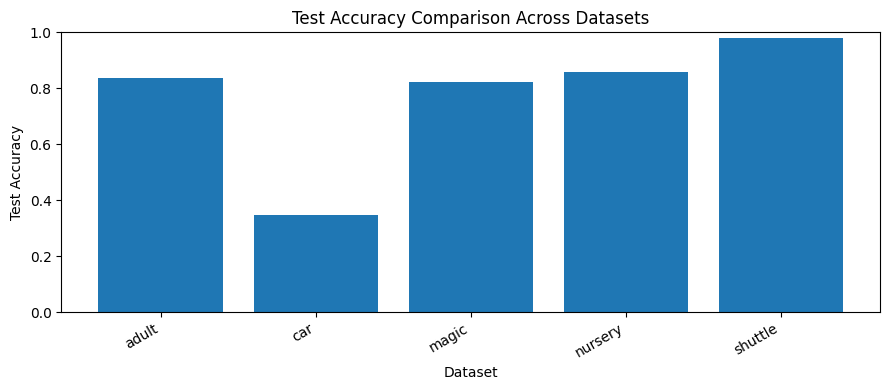

In [35]:
import matplotlib.pyplot as plt
for c in ["rows", "test_accuracy", "test_f1_macro"]:
    df_scores[c] = pd.to_numeric(df_scores[c], errors="coerce")

# Sort by dataset name (or change to sort by metric later)
dfp = df_scores.sort_values("dataset").reset_index(drop=True)
dfp

plt.figure(figsize=(9, 4))
plt.bar(dfp["dataset"], dfp["test_accuracy"])
plt.ylabel("Test Accuracy")
plt.xlabel("Dataset")
plt.ylim(0, 1.0)
plt.title("Test Accuracy Comparison Across Datasets")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
